In [1]:
import os
import pandas as pd
import numpy as np
import xarray as xr


In [2]:
#hay que escoger la bbox en todos igual
min_lon, min_lat, max_lon, max_lat = [-69.61, -60., -50., -32.45] #bbox of our study

In [3]:
filepath = "../../ARVI-IEO/IEO/DATA_ANALYSIS/unir_db_py/data_output/2005-2024.csv"
df = pd.read_csv(filepath, low_memory=False)
df["FechaCaptura"] = pd.to_datetime(df["FechaCaptura"], format="mixed")
df.columns

Index(['IdCaptura', 'NombreBuque', 'CodigoBuque', 'ZonaFAO', 'ArteFAO',
       'FechaCaptura', 'Lat', 'Lon', 'NumOperaciones', 'TiempoPesca',
       'EspecieFAO', 'ValorMalla', 'Peso', 'Unnamed: 0'],
      dtype='object')

In [4]:
df1 = df[["FechaCaptura","NombreBuque", "Lat", "Lon", "Peso", "TiempoPesca", "NumOperaciones", "EspecieFAO" ]] # Select only the necessary columns
df1= df1.dropna(subset=["Lat", "Lon"])
df1[["Lat", "Lon"]] = df1[["Lat", "Lon"]].apply(lambda x: -abs(x)) #correccion de las posiciones
len(df1) #alrededor del 10% de los registros no tienen puntos valido, se podría ver para rescatar las capturas de estos registros con la ultima posición conocida del buque o mediante GFW.

df1["Lat"] = df1["Lat"].round(1)
df1["Lon"] = df1["Lon"].round(1)

df1 = df1[
    (df1['Lon'] >= min_lon) & (df1['Lon'] <= max_lon) &
    (df1['Lat'] >= min_lat) & (df1['Lat'] <= max_lat)
    ] #solo datos del area de interés 

df1['Fecha'] = df1['FechaCaptura'].dt.to_period('M').dt.to_timestamp()

df1_agg = (
    df1.groupby(["Fecha","EspecieFAO", "Lat", "Lon"], as_index=False)
      .agg(PesoTotal=('Peso', 'sum'))
)

lances = df1[["FechaCaptura", "NombreBuque", "Lat", "Lon", "Peso", "TiempoPesca", "NumOperaciones"]].drop_duplicates()
lances['Fecha'] = lances['FechaCaptura'].dt.to_period('M').dt.to_timestamp()
effort = lances.groupby(["Fecha", "Lat", "Lon"]).agg(Horas=('TiempoPesca', 'sum')).reset_index()
effort["Horas"] = effort["Horas"].div(60)
display(effort)




,Fecha,Lat,Lon,Horas
0,2006-01-01,-52.3,-63.2,120.000000
1,2006-01-01,-51.9,-63.1,91.000000
2,2006-01-01,-51.8,-63.4,247.000000
3,2006-01-01,-51.7,-63.5,391.000000
4,2006-01-01,-51.7,-63.4,256.000000
...,...,...,...,...
32852,2024-12-01,-45.9,-60.8,69.416667
32853,2024-12-01,-45.9,-60.7,130.500000
32854,2024-12-01,-45.8,-60.7,304.333333
32855,2024-12-01,-45.7,-60.7,281.666667


#### Creación de grid

In [5]:
res = 0.1
lat_grid = np.arange(min_lat, max_lat + res, res)
lon_grid = np.arange(min_lon, max_lon + res, res)

df1_agg['lat_bin'] = pd.cut(df1_agg['Lat'], bins=lat_grid, labels=lat_grid[:-1])
df1_agg['lon_bin'] = pd.cut(df1_agg['Lon'], bins=lon_grid, labels=lon_grid[:-1])

effort["lat_bin"] = pd.cut(effort["Lat"], bins=lat_grid, labels=lat_grid[:-1])
effort["lon_bin"] = pd.cut(effort["Lon"], bins=lon_grid, labels=lon_grid[:-1])

df1_grid = df1_agg.groupby(['Fecha', "lat_bin", "lon_bin", 'EspecieFAO'], observed=True)['PesoTotal'].sum().reset_index() #True no rellena con NaN cuando no hay datos
effort_grid = effort.groupby(['Fecha', "lat_bin", "lon_bin"], observed=True)['Horas'].sum().reset_index() #True no rellena con NaN cuando no hay datos

In [6]:
dsxr = (
    df1_grid
    .set_index(["Fecha", "lat_bin", "lon_bin", "EspecieFAO"]) #we define the xarray coordinates
    .to_xarray()
    .rename({"Fecha": "time", "lat_bin":"lat", "lon_bin":"lon", "EspecieFAO":"FAOspp"})
) #we convert the pandas dataframe to a xarray

# Define chunk sizes for dask, time in 12-month chunks, lat and lon full size, geartype and flag one at a chunk. 
chunks = {"time": 12, "lat": -1, "lon": -1, "FAOspp":1}
dsxr = dsxr.chunk(chunks)

dsxr = dsxr.reindex(lat=lat_grid, lon=lon_grid)
dsxr = dsxr.assign_coords(
    lat=dsxr["lat"].astype(str).astype(float),
    lon=dsxr["lon"].astype(str).astype(float)
)

dsxr_effort = (
    effort_grid
    .set_index(["Fecha", "lat_bin", "lon_bin"])
    .to_xarray()
    .rename({"Fecha": "time", "lat_bin":"lat", "lon_bin":"lon"})
    )
dsxr_effort = dsxr_effort.reindex(lat=lat_grid, lon=lon_grid)
dsxr_effort = dsxr_effort.assign_coords(
    lat=dsxr_effort["lat"].astype(str).astype(float),
    lon=dsxr_effort["lon"].astype(str).astype(float)
    )

c:\Users\rubar\miniconda3\envs\TFMenv\lib\site-packages\dask\array\core.py:5189: PerformanceWarning: Increasing number of chunks by factor of 72
  result = blockwise(


In [ ]:
SQA = dsxr.sel(FAOspp="SQA", drop=True)
HKP = dsxr.sel(FAOspp="HKP", drop=True)
SQA.to_netcdf(f"./data/processed/targets/SQA_{res}.nc", mode="w")
HKP.to_netcdf(f"./data/processed/targets/HKP_{res}.nc", mode="w")


c:\Users\rubar\miniconda3\envs\TFMenv\lib\site-packages\dask\_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
c:\Users\rubar\miniconda3\envs\TFMenv\lib\site-packages\dask\_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
c:\Users\rubar\miniconda3\envs\TFMenv\lib\site-packages\dask\_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
c:\Users\rubar\miniconda3\envs\TFMenv\lib\site-packages\dask\_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
c:\Users\rubar\miniconda3\envs\TFMenv\lib\site-packages\dask\_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
c:\Users\rubar\miniconda3\envs\TFMenv\lib\site-packages\dask\_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
c:\User

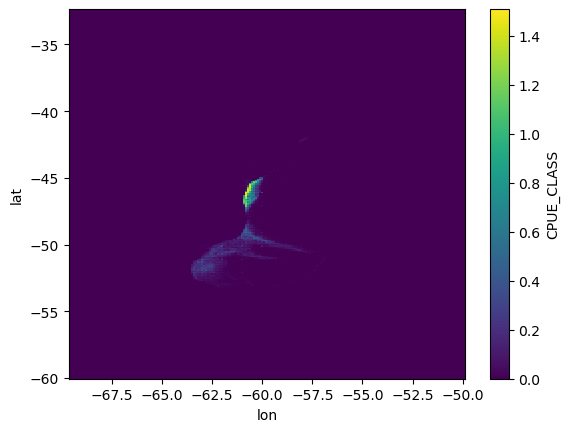

In [9]:
# 5th percentile threshold of effort
effort_pq = dsxr_effort["Horas"].quantile(0.10)

# Keep only cells with effort >= 5th percentile
effort_mask = dsxr_effort["Horas"] >= effort_pq
# Compute CPUE with masking
cpue_index_HKP = xr.where(effort_mask, np.log1p(HKP["PesoTotal"]) - np.log1p(dsxr_effort["Horas"] + 1e-6),np.nan)

CPUE_real = HKP["PesoTotal"] / dsxr_effort["Horas"]

pq_10 = CPUE_real.quantile(0.01, dim=("lat", "lon"))
pq_50 = CPUE_real.quantile(0.5, dim=("lat", "lon"))

cpue_class_HKP = xr.where(CPUE_real > pq_50, 2, xr.where(CPUE_real > pq_10, 1, 0)) #for above 50% CPUE, class 2 and for above 10% CPUE class 1


cpue_index_HKP = cpue_index_HKP.fillna(0)
cpue_index_HKP = cpue_index_HKP.drop_vars("quantile")
cpue_index_HKP=cpue_index_HKP.to_dataset(name="CPUE")
cpue_class_HKP=cpue_class_HKP.to_dataset(name="CPUE_CLASS")

cpue_index_HKP.to_netcdf(f"./data/processed/targets/cpue_HKP_{res}.nc", mode="w")
cpue_class_HKP.to_netcdf(f"./data/processed/targets/cpue_class_HKP_{res}.nc", mode="w")


cpue_class_HKP["CPUE_CLASS"].mean(dim="time").plot()